# Satellite images data analysis 

This notebook is used for performing a data anlaysis on the available satellite images of <code>JRC</code> collection. Specifically, the statistics of the occurrence of the three pixel classes (<code>0: no-data, 1: non-water, 2: water</code>) were explored in order to implement an efficient and valuable algorithm for the dataset creation, which can ensure to have a large enough amount of data to train the model as well as ensure a good quality of the data itself.

**<span style="color:red">Attention!</span> Don't run the whole notebook to avoid the overwriting of <code>*.csv</code> files. The cells that generate those files are located at the end of the notebook.**

In [1]:
# move to root directory

%cd .. 

c:\Users\magherin\Desktop\jamuna_morpho


In [2]:
# reload modules to avoid restarting the notebook every time these are updated

%load_ext autoreload
%autoreload 2

In [3]:
# import modules 

import os
import copy

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

from preprocessing.images_analysis import *
from postprocessing.satellite_analysis_post import plot_input_images

# suppress SettingCopyWarning
pd.options.mode.chained_assignment = None

Set default visualization parameters for grayscale images (suited only for JRC dataset). If RGB images are displayed or images from other collections these should be manually adjusted.

In [4]:
plt.rcParams['image.cmap'] = 'gray'
vmin = 0
vmax = 2

Directories of original and preprocessed images. 

In [5]:
dir_orig = r'data\satellite\original'
dir_proc = r'data\satellite\preprocessed'

Available collections.

In [6]:
L5 = r'LANDSAT_LT05_C02_T1_L2'
JRC = r'JRC_GSW1_4_MonthlyHistory'
S1 = r'COPERNICUS_S1_GRD'

Set training, validation and testing strings.

In [7]:
train = 'training'
val = 'validation'
test = 'testing'

train_val_test_list = [train, val, test]

In [8]:
# create directory strings for all folders

# training reaches don't have a reach_id - it needs to be looped through/specified somehow when functions are run
train_orig = os.path.join(dir_orig, JRC + f'_{train}_r')
train_pre = os.path.join(dir_proc, JRC + f'_{train}')

val_orig = os.path.join(dir_orig, JRC + f'_{val}_r1')
val_pre = os.path.join(dir_proc, JRC + f'_{val}_r1')

test_orig = os.path.join(dir_orig, JRC + f'_{test}_r1')
test_pre = os.path.join(dir_proc, JRC + f'_{test}_r1')

c:\Users\magherin\AppData\Local\anaconda3\envs\braided\lib\site-packages\osgeo\gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


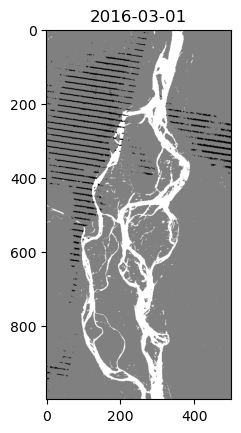

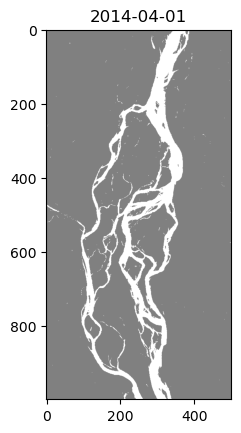

In [10]:
img_1 = show_image_array(r'data\satellite\original\JRC_GSW1_4_MonthlyHistory_testing_r1\2016_03_01_testing_r1.tif')
img_2 = show_image_array(r'data\satellite\original\JRC_GSW1_4_MonthlyHistory_testing_r1\2014_04_01_testing_r1.tif')

No clue why but when taking the element-wise difference 1 - 2 = 255 (and I guess 0 - 2 = 254).

In [9]:
cond = (img_1 == 2) & (img_2 == 1) 
shape = np.shape(cond)
list = []
for i in range(0,shape[0]):
    for j in range(0, shape[1]):
        if cond[i,j] == True:
            list.append([i,j])

In [10]:
diff_test = img_2 - img_1
cond = (diff_test == 255)
list_255 = []
shape = np.shape(cond)
for i in range(0,shape[0]):
    for j in range(0, shape[1]):
        if cond[i,j] == True:
            list_255.append([i,j])

In [11]:
len(list), len(list_255)

(22689, 22689)

In [12]:
list == list_255

True

In [13]:
diff = compute_diff(train, 1)

In [14]:
diff.describe()

,Different pixels
count,408.000000
mean,61180.730392
std,95630.307710
min,0.000000
25%,0.000000
50%,11611.000000
75%,83158.250000
max,405565.000000


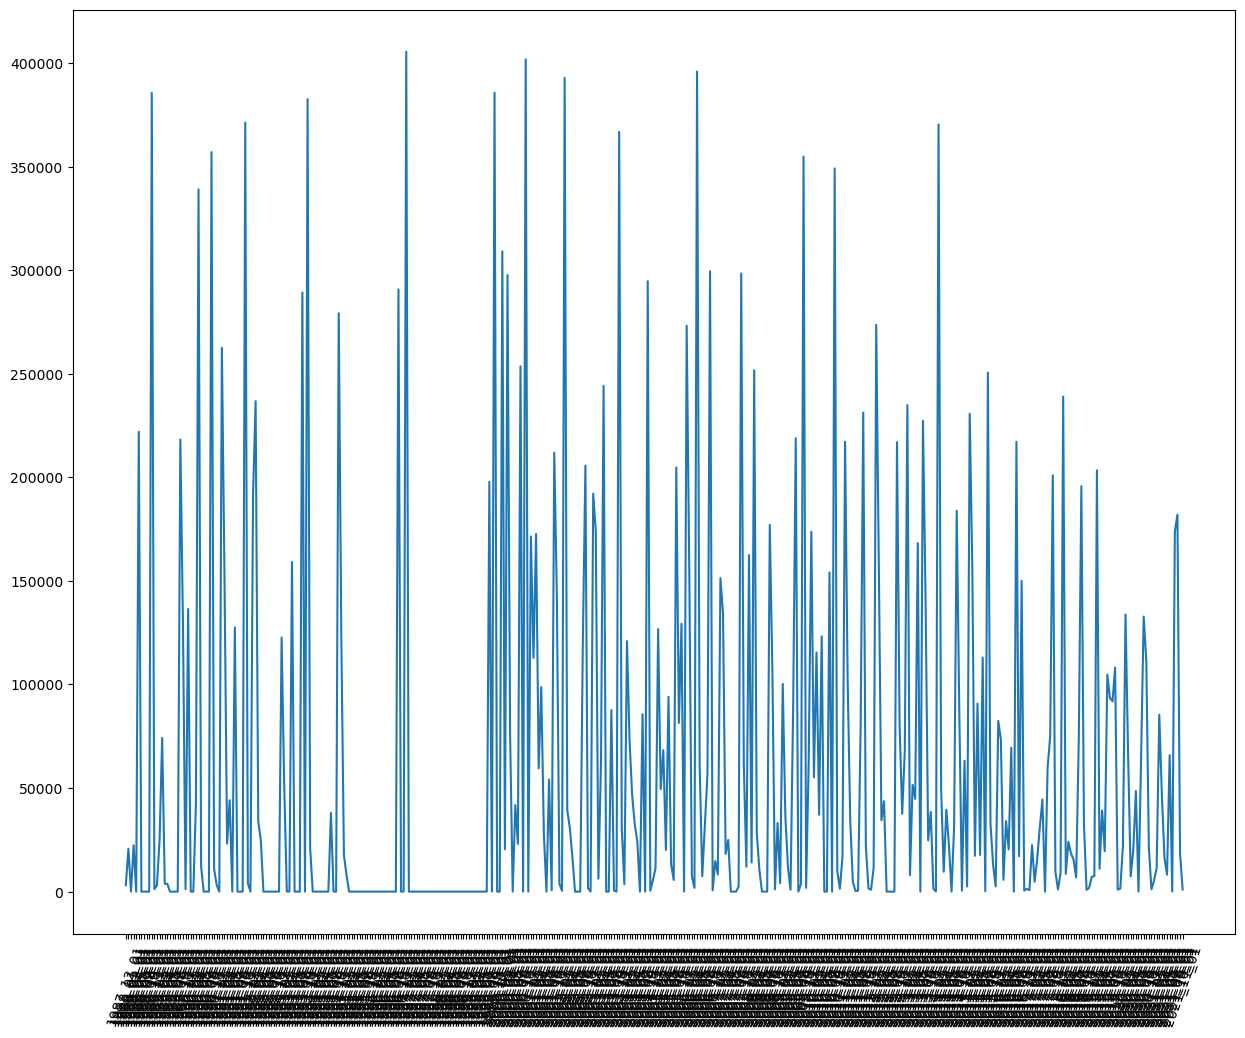

In [15]:
plt.figure(figsize=(15,12))
plt.plot(diff['Start date'], diff['Different pixels'])
plt.xticks(rotation=70)
plt.show()

In [16]:
clean_diff = copy.deepcopy(diff)
cond = ['05_01', '06_01', '07_01', '08_01', '09_01']

for row in range(len(clean_diff) - 1, -1, -1):
    if any(substring in clean_diff['Start date'].iloc[row] for substring in cond):
        clean_diff = clean_diff.drop(row)

clean_diff = clean_diff.reset_index(drop=True) 

In [17]:
clean_diff = clean_diff[clean_diff['Different pixels'] <= 250000]
clean_diff

,Start date,End date,Different pixels
0,1987_12_01,1988_01_01,3079
1,1988_01_01,1988_02_01,20677
2,1988_02_01,1988_03_01,0
3,1988_03_01,1988_04_01,22374
4,1988_04_01,1988_05_01,0
...,...,...,...
228,2021_02_01,2021_03_01,85400
229,2021_03_01,2021_04_01,46871
230,2021_04_01,2021_05_01,16291
231,2021_10_01,2021_11_01,18654


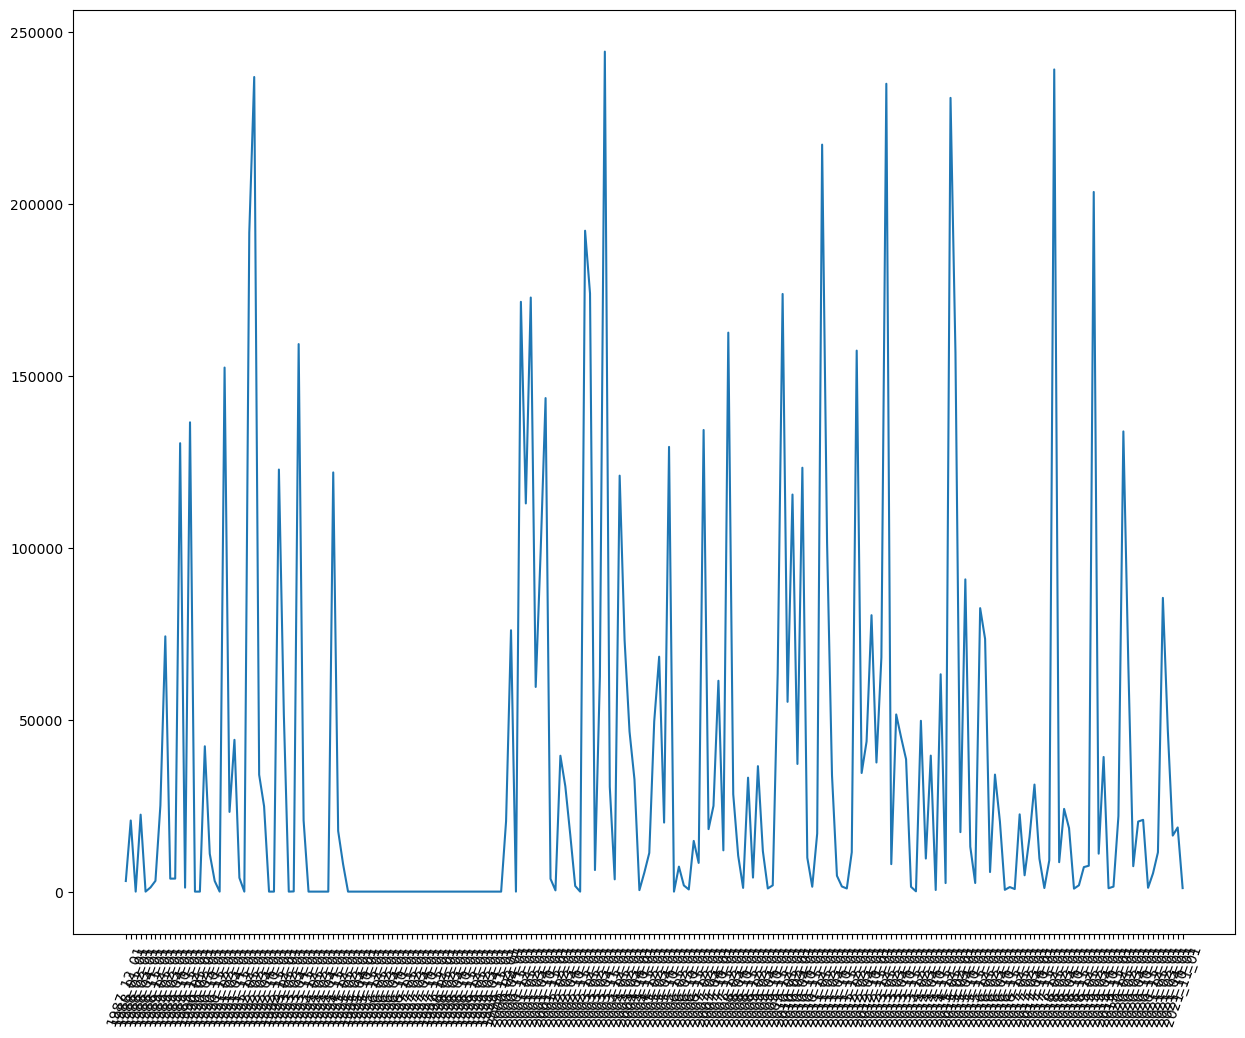

In [18]:
plt.figure(figsize=(15,12))
plt.plot(clean_diff['Start date'], clean_diff['Different pixels'])
plt.xticks(rotation=70)
plt.show()

##### Training

In [10]:
# this is not needed actually, as it is already implemented within `create_long_df` 
# it is added just to show the outcome of the function

dfs_train = load_all_csv(train)
dfs_train

[                 Date image  no-data: 0  non-water: 1  water: 2
 0    1987_12_01_training_r1        9513        406447     84040
 1    1988_01_01_training_r1       29665        399386     70949
 2    1988_02_01_training_r1       46438        389517     64045
 3    1988_03_01_training_r1      500000             0         0
 4    1988_04_01_training_r1      460296         22374     17330
 ..                      ...         ...           ...       ...
 404  2021_08_01_training_r1      500000             0         0
 405  2021_09_01_training_r1      243461        173936     82603
 406  2021_10_01_training_r1       20203        352759    127038
 407  2021_11_01_training_r1         510        397762    101728
 408  2021_12_01_training_r1       46973        383511     69516
 
 [409 rows x 4 columns],
                  Date image  no-data: 0  non-water: 1  water: 2
 0    1987_12_01_training_r2        8661        405050     86289
 1    1988_01_01_training_r2       27045        400067     7288

In [11]:
df_train = create_long_df(train)
df_train

,Date image,no-data: 0,non-water: 1,water: 2
0,1987_12_01_training_r1,9513,406447,84040
1,1988_01_01_training_r1,29665,399386,70949
2,1988_02_01_training_r1,46438,389517,64045
3,1988_03_01_training_r1,500000,0,0
4,1988_04_01_training_r1,460296,22374,17330
...,...,...,...,...
11447,2021_08_01_training_r28,127017,255229,117641
11448,2021_09_01_training_r28,1132,321660,177208
11449,2021_10_01_training_r28,880,374285,124835
11450,2021_11_01_training_r28,4282,425801,69912


In [12]:
df_train.describe()

,no-data: 0,non-water: 1,water: 2
count,11452.000000,11452.000000,11452.000000
mean,243800.152986,209956.697171,46231.547852
std,213258.418669,182613.726875,45961.995212
min,0.000000,0.000000,0.000000
25%,20835.000000,0.000000,0.000000
50%,191392.500000,229456.500000,42836.500000
75%,500000.000000,397284.500000,71081.750000
max,500000.000000,473121.000000,277737.000000


In [13]:
ratio_wnw = df_train['water: 2']/df_train['non-water: 1'] 

ratio_wnw[np.isnan(ratio_wnw)] = 0
ratio_wnw[np.isinf(ratio_wnw)] = 0

ratio_wnw_df = pd.DataFrame(ratio_wnw)
ratio_wnw_df.describe()

,0
count,11452.000000
mean,3.288569
std,122.752349
min,0.000000
25%,0.000000
50%,0.134172
75%,0.259754
max,9293.000000


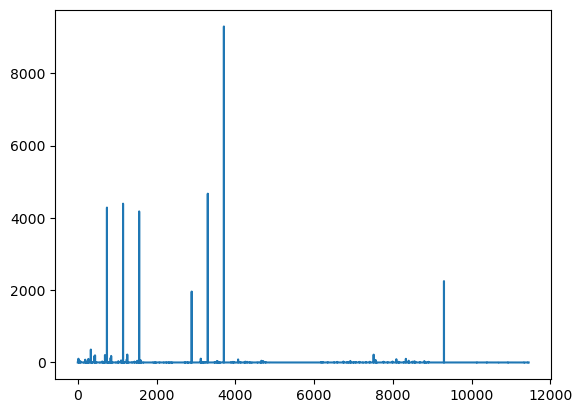

In [14]:
plt.plot(ratio_wnw_df[0])

In [15]:
corr_matrix_train = df_train[['no-data: 0', 'non-water: 1', 'water: 2']].corr()
corr_matrix_train

,no-data: 0,non-water: 1,water: 2
no-data: 0,1.000000,-0.984924,-0.726579
non-water: 1,-0.984924,1.000000,0.596770
water: 2,-0.726579,0.596770,1.000000


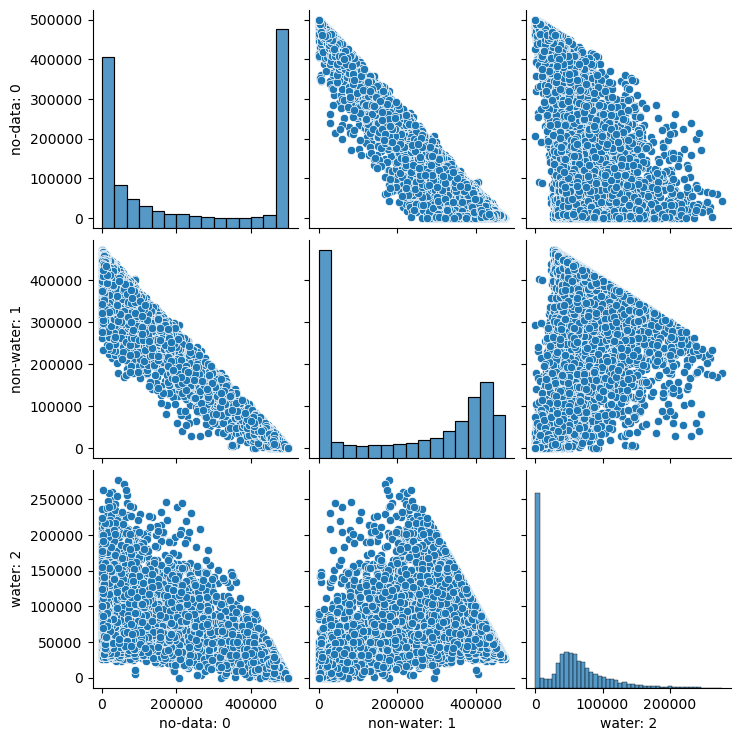

In [16]:
sns.pairplot(df_train[['no-data: 0', 'non-water: 1', 'water: 2']])
plt.show()

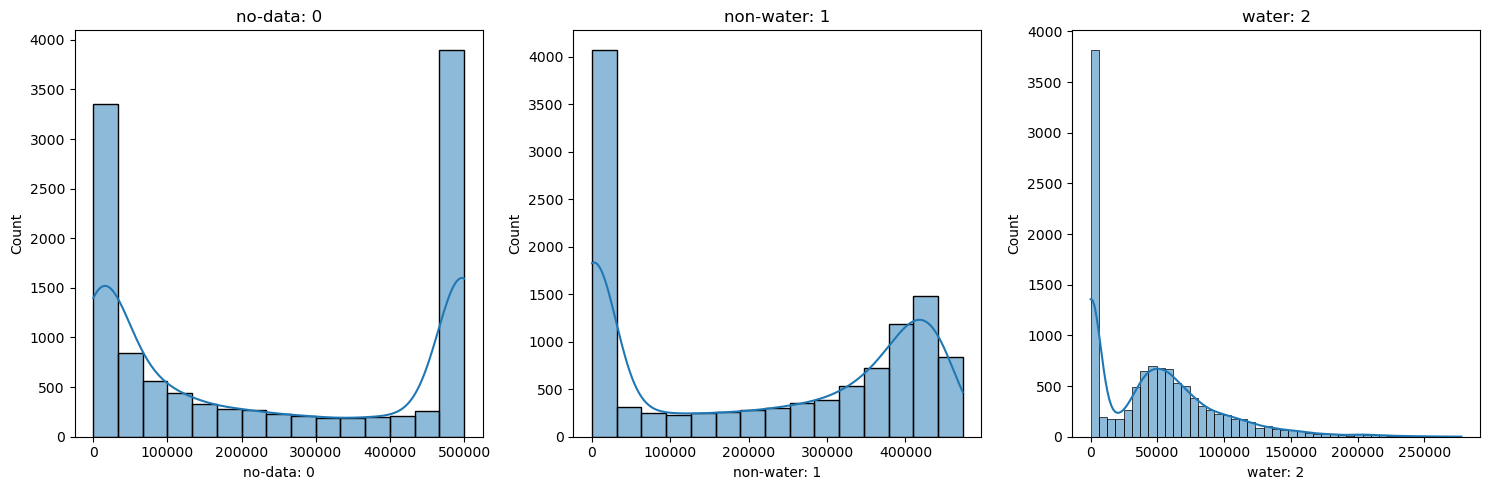

In [17]:
# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

# Plot distribution of each column
for i, column in enumerate(df_train.columns[1:]):
    sns.histplot(df_train[column], kde=True, ax=axes[i])
    axes[i].set_title(column)

plt.tight_layout()
plt.show()

# sns.displot(clean_df_train['no-data: 0'], kde=True)

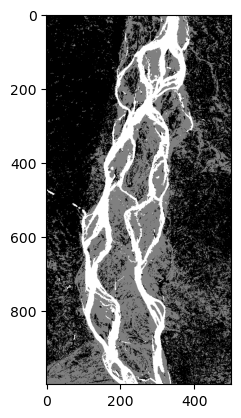

In [26]:
img_array = show_image_array(r'data\satellite\preprocessed\JRC_GSW1_4_MonthlyHistory_testing_r1\2001_01_01_testing_r1.tif')

In [27]:
traindf = pd.read_csv(r'data\satellite\preprocessed\cleared_csv\training_cleared_nodata350000_water10000.csv')
valdf = pd.read_csv(r'data\satellite\preprocessed\cleared_csv\validation_cleared_nodata350000_water10000.csv')
testdf = pd.read_csv(r'data\satellite\preprocessed\cleared_csv\testing_cleared_nodata350000_water10000.csv')

In [28]:
train_dataset, train_missing = monthly_combinations(traindf)
len(train_dataset)

409

In [29]:
train_dataset

[['1987_12_01', '1988_12_01', '1989_12_01', '1990_12_01', '1991_12_01'],
 ['1987_12_01', '1988_12_01', '1989_12_01', '1990_12_01', '1991_12_01'],
 ['1987_12_01', '1988_12_01', '1989_12_01', '1990_12_01', '1991_12_01'],
 ['1987_12_01', '1988_12_01', '1989_12_01', '1990_12_01', '1991_12_01'],
 ['1987_12_01', '1988_12_01', '1989_12_01', '1990_12_01', '1991_12_01'],
 ['1987_12_01', '1988_12_01', '1989_12_01', '1990_12_01', '1991_12_01'],
 ['1987_12_01', '1988_12_01', '1989_12_01', '1990_12_01', '1991_12_01'],
 ['1987_12_01', '1988_12_01', '1989_12_01', '1990_12_01', '1991_12_01'],
 ['1987_12_01', '1988_12_01', '1989_12_01', '1990_12_01', '1991_12_01'],
 ['1987_12_01', '1988_12_01', '1989_12_01', '1990_12_01', '1991_12_01'],
 ['1987_12_01', '1988_12_01', '1989_12_01', '1990_12_01', '1991_12_01'],
 ['1987_12_01', '1988_12_01', '1989_12_01', '1990_12_01', '1991_12_01'],
 ['1987_12_01', '1988_12_01', '1989_12_01', '1990_12_01', '1991_12_01'],
 ['1987_12_01', '1988_12_01', '1989_12_01', '1990_1

In [30]:
val_dataset, val_missing = monthly_combinations(valdf)
len(val_dataset)

0

In [31]:
test_dataset, test_missing = monthly_combinations(testdf)
len(test_dataset)

0

In [32]:
def get_info_cleared_df(nodata_thr, water_thr, dir_folders = r'data\satellite\preprocessed\cleared_csv'):
    '''
    This function is used to evaluate all available images necessary for the dataset creation for each possible combination of no-data and water thresholds. 
    It first loads all dataframes (training, validation and testing), concatenates these and then groups them based on 'Use' and 'Reach id'.

    Inputs:
           nodata_thr = int, max acceptable amount of no-data pixels 
           water_thr = int, max acceptable amount of water pixels
           dir_folders = str, dirtectory where the original .csv files are stored
                        default: r'data\satellite\preprocessed'
           
    Output: 
           grouped = grouped df by 'Use' and 'Reach id'
    '''
    # initiate lists
    train_val_test_list = ['training', 'validation', 'testing']
    filenames = []
    filepaths = []

    # loop through uses to load dataframes
    for train_val_test in train_val_test_list:
        filename = fr'{train_val_test}_cleared_nodata{nodata_thr}_water{water_thr}.csv'
        filepath = os.path.join(dir_folders, filename)
        
        filenames.append(filename)
        filepaths.append(filepath)
    
    # load dfs
    df_train = pd.read_csv(filepaths[0]) 
    df_val = pd.read_csv(filepaths[1])
    df_test = pd.read_csv(filepaths[2])

    # get total number of reaches per each use
    _, reaches_train = df_train['Date image'].iloc[-1].split('_r', 1) 
    _, reaches_val = df_val['Date image'].iloc[-1].split('_r', 1)
    _, reaches_test = df_test['Date image'].iloc[-1].split('_r', 1)

    # create lists with reach ids given total number of reaches per use
    reach_ids_train = [i for i in range(1, int(reaches_train) + 1)]
    reach_ids_val = [i for i in range(1, int(reaches_val) + 1)]
    reach_ids_test = [i for i in range(1, int(reaches_test) + 1)]

    # concat dfs
    concat = pd.concat([df_train, df_val, df_test])
    
    # create new columns
    usage = [concat['Date image'].iloc[i].split('_')[-2] for i in range(len(concat))] # training, validation and testing
    reach_id = [concat['Date image'].iloc[i].split('_r', 1)[-1] for i in range(len(concat))] # int from 1 to total number of reaches per use
    concat['Use'], concat['Reach id'] = usage, reach_id
    
    # group dataframe by 'Use' and 'Reach id'
    grouped = concat.groupby(['Use', 'Reach id'], as_index=False)
    return grouped

In [33]:
comb_test = get_info_cleared_df(250000, 15000)
comb_test

In [34]:
for use_reach, pixels in comb_test:
    print(f'Total images group {use_reach}: {len(pixels)}\n')

Total images group ('testing', '1'): 152

Total images group ('training', '1'): 129

Total images group ('training', '10'): 152

Total images group ('training', '11'): 149

Total images group ('training', '12'): 148

Total images group ('training', '13'): 149

Total images group ('training', '14'): 172

Total images group ('training', '15'): 151

Total images group ('training', '16'): 134

Total images group ('training', '17'): 121

Total images group ('training', '18'): 101

Total images group ('training', '19'): 101

Total images group ('training', '2'): 125

Total images group ('training', '20'): 133

Total images group ('training', '21'): 140

Total images group ('training', '22'): 116

Total images group ('training', '23'): 106

Total images group ('training', '24'): 106

Total images group ('training', '25'): 100

Total images group ('training', '26'): 97

Total images group ('training', '27'): 100

Total images group ('training', '28'): 98

Total images group ('training', '3'): 

In [35]:
no_data = np.sum(np.where(img_array == 0, 1, 0))
water = np.sum(np.where(img_array == 2, 1, 0))
print(f'Total "no-data" pixels: {no_data}.\n\
Total "water" pixels: {water}.\n\
Ratio water/nodata: {water/no_data:.2f}')

Total "no-data" pixels: 254863.
Total "water" pixels: 65960.
Ratio water/nodata: 0.26


In [36]:
nodata_thr = 350000
water_thr = 25000

clean_df_train = copy.deepcopy(df_train)
clean_df_train = clean_df_train[(clean_df_train['no-data: 0'] <= nodata_thr) & (clean_df_train['no-data: 0'] >= water_thr)]
clean_df_train.describe()

,no-data: 0,non-water: 1,water: 2
count,3750.000000,3750.000000,3750.000000
mean,136638.219200,290476.395733,72859.857600
std,92302.274936,96108.593211,41325.404816
min,25024.000000,5480.000000,0.000000
25%,56469.500000,215516.500000,44384.750000
50%,111691.000000,306618.500000,61756.000000
75%,204430.750000,372634.000000,89041.750000
max,349974.000000,445336.000000,277737.000000


In [37]:
corr_matrix_train_clean = clean_df_train[['no-data: 0', 'non-water: 1', 'water: 2']].corr()
corr_matrix_train_clean

,no-data: 0,non-water: 1,water: 2
no-data: 0,1.000000,-0.904505,-0.130197
non-water: 1,-0.904505,1.000000,-0.305069
water: 2,-0.130197,-0.305069,1.000000


In [38]:
correlation_coefficient, p_value = spearmanr(clean_df_train['no-data: 0'], clean_df_train['water: 2'])
correlation_coefficient, p_value

(-0.11511535232568422, 1.5436282631176119e-12)

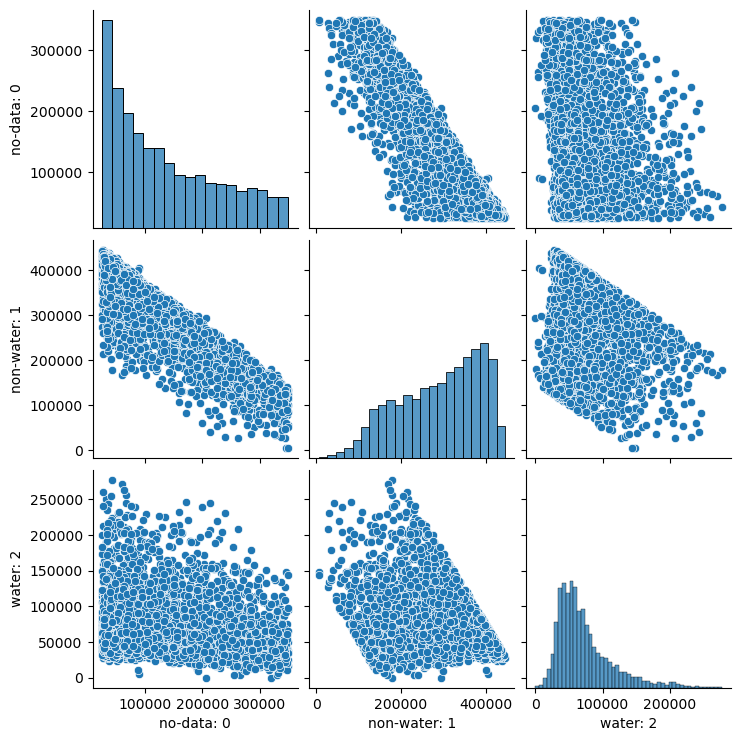

In [39]:
sns.pairplot(clean_df_train[['no-data: 0', 'non-water: 1', 'water: 2']])
plt.show()

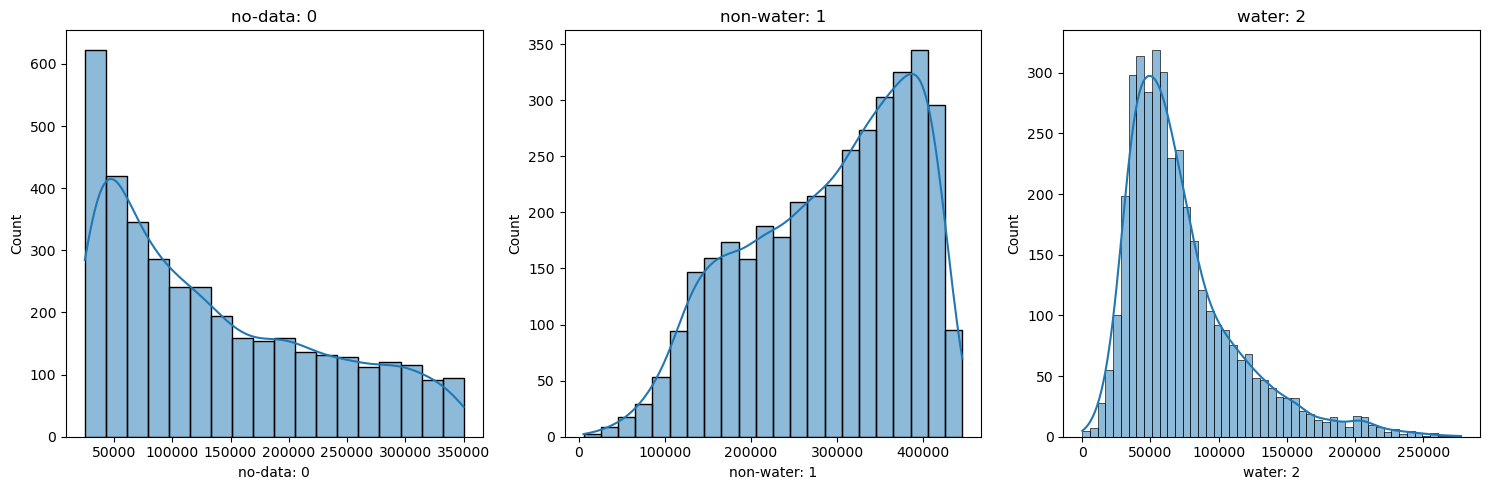

In [41]:
# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

# Plot distribution of each column
for i, column in enumerate(clean_df_train.columns[1:]):
    sns.histplot(clean_df_train[column], kde=True, ax=axes[i])
    axes[i].set_title(column)

plt.tight_layout()
plt.show()

# sns.displot(clean_df_train['no-data: 0'], kde=True)

In [43]:
get_info_images(df_train, 0.6)

Total images: 11452.
Completely cloudy images: 3281.
Perfect (no clouds) images: 49.
Images usable (no-data pixels threshold = 300000): 6508.


##### Validation

In [44]:
df_val = create_long_df(val)
df_val.describe()

,no-data: 0,non-water: 1,water: 2
count,409.000000,409.000000,409.000000
mean,244980.723716,200432.202934,54587.073350
std,205080.058355,172295.569549,48252.763613
min,0.000000,0.000000,0.000000
25%,26629.000000,0.000000,0.000000
50%,204862.000000,200958.000000,55018.000000
75%,500000.000000,373171.000000,79921.000000
max,500000.000000,451072.000000,224435.000000


In [45]:
nodata_thr = 350000
water_thr = 25000

clean_df_val = copy.deepcopy(df_val)
clean_df_val = clean_df_val[(clean_df_val['no-data: 0'] <= nodata_thr) & (clean_df_val['no-data: 0'] >= water_thr)]
clean_df_val.describe()

,no-data: 0,non-water: 1,water: 2
count,149.000000,149.000000,149.000000
mean,156595.053691,261097.758389,82307.187919
std,96755.074468,98340.262183,42120.793961
min,25737.000000,30020.000000,26705.000000
25%,68498.000000,177579.000000,58334.000000
50%,140665.000000,276846.000000,67031.000000
75%,228459.000000,356032.000000,95981.000000
max,349995.000000,418298.000000,224435.000000


##### Testing

In [46]:
df_test = create_long_df(test)
df_test.describe()

,no-data: 0,non-water: 1,water: 2
count,409.000000,409.000000,409.000000
mean,208478.845966,224260.723716,67260.430318
std,203620.517723,172405.417047,55211.643653
min,0.000000,0.000000,0.000000
25%,16160.000000,1334.000000,14466.000000
50%,131383.000000,266727.000000,64018.000000
75%,475210.000000,392648.000000,92778.000000
max,500000.000000,448898.000000,251830.000000


In [47]:
nodata_thr = 350000
water_thr = 25000

clean_df_test = copy.deepcopy(df_test)
clean_df_test = clean_df_test[(clean_df_test['no-data: 0'] <= nodata_thr) & (clean_df_test['no-data: 0'] >= water_thr)]
clean_df_test.describe()

,no-data: 0,non-water: 1,water: 2
count,160.000000,160.00000,160.000000
mean,134356.506250,268382.47500,97261.018750
std,88226.239236,101013.26821,50016.771291
min,25244.000000,23793.00000,36110.000000
25%,54704.750000,185041.75000,62609.750000
50%,119804.500000,281162.00000,75117.000000
75%,195341.500000,354670.00000,124694.750000
max,344622.000000,426630.00000,251830.000000


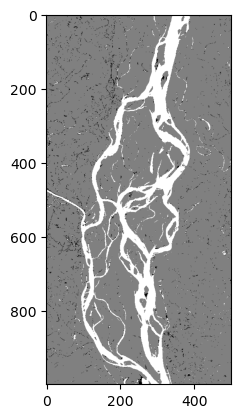

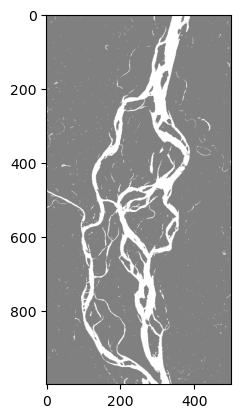

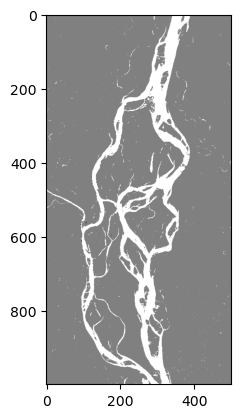

In [48]:
img_good1 = show_image_array(r'data\satellite\preprocessed\JRC_GSW1_4_MonthlyHistory_testing_r1\2017_01_01_testing_r1.tif')
img_bad = show_image_array(r'data\satellite\preprocessed\JRC_GSW1_4_MonthlyHistory_testing_r1\2017_02_01_testing_r1.tif')
img_good2 = show_image_array(r'data\satellite\preprocessed\JRC_GSW1_4_MonthlyHistory_testing_r1\2017_03_01_testing_r1.tif')

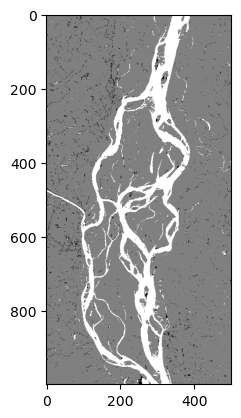

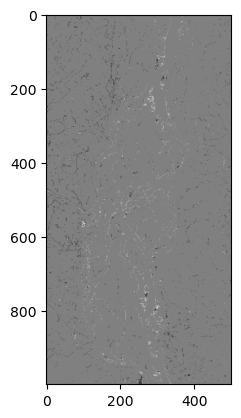

In [49]:
averaged_image = np.round(((img_good2+img_good1)/2),0)
diff_image = averaged_image - img_bad
plt.imshow(averaged_image, vmin=vmin, vmax=vmax)
plt.show()
plt.imshow(diff_image, vmin=-2, vmax=2)
plt.show()

In [50]:
for i in range(-2,3):
    print(f'{i}: {len(diff_image[diff_image==i])}')

-2: 207
-1: 10612
0: 482371
1: 6801
2: 9


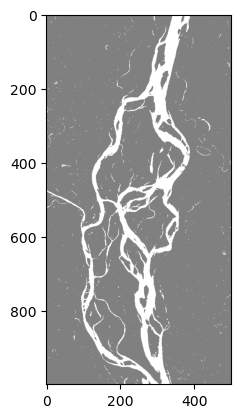

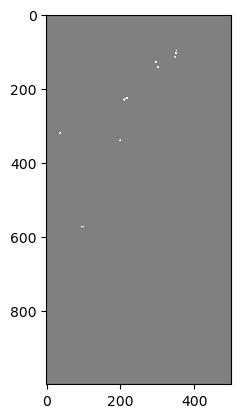

In [51]:
zero_indeces = img_bad == 0
img_bad_improved = img_bad.copy()  
img_bad_improved[zero_indeces] = averaged_image[zero_indeces]
diff_image_improved = img_bad - img_bad_improved
plt.imshow(img_bad_improved, vmin=vmin, vmax=vmax)
plt.show()
plt.imshow(diff_image_improved, vmin=-2, vmax=2)
plt.show()

In [56]:
# print pixels differences for each value
# between -3 and 256 unless there is no value like that  

for i in range(-3,257):
    if len(diff_image_improved[diff_image_improved==i]) != 0:
        print(f'{i}: {len(diff_image_improved[diff_image_improved==i])}')

0: 499988
254: 9
255: 3


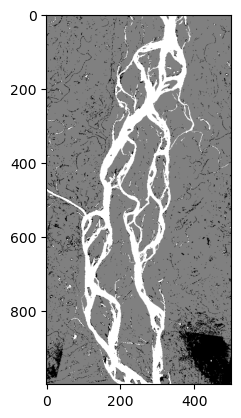

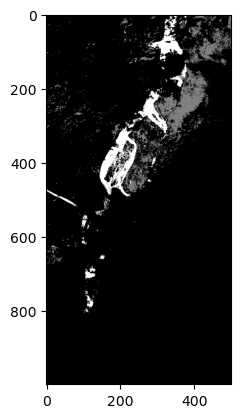

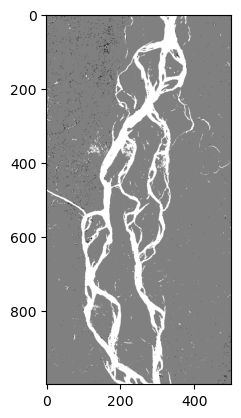

In [57]:
img_good1 = show_image_array(r'data\satellite\preprocessed\JRC_GSW1_4_MonthlyHistory_testing_r1\2001_12_01_testing_r1.tif')
img_bad = show_image_array(r'data\satellite\preprocessed\JRC_GSW1_4_MonthlyHistory_testing_r1\2002_01_01_testing_r1.tif')
img_good2 = show_image_array(r'data\satellite\preprocessed\JRC_GSW1_4_MonthlyHistory_testing_r1\2002_02_01_testing_r1.tif')

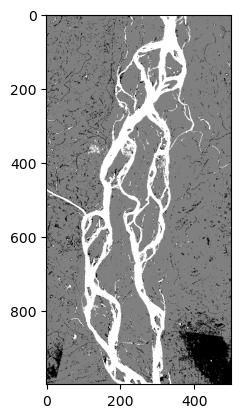

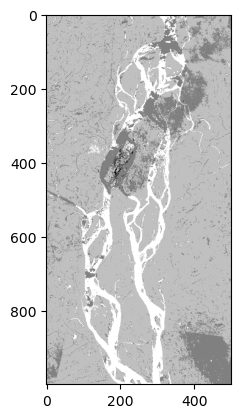

In [58]:
# interpolated_image = (img_good2-img_good1) * (4 - 2) / (3 - 2) + img_good1
averaged_image = np.round(((img_good2+img_good1)/2),0)
diff_image = averaged_image - img_bad
# plt.imshow(interpolated_image, vmin=vmin, vmax=vmax)
# plt.show()
plt.imshow(averaged_image, vmin=vmin, vmax=vmax)
plt.show()
plt.imshow(diff_image, vmin=-2, vmax=vmax)
plt.show()

In [62]:
for i in range(-3,257):
    if len(diff_image[diff_image==i]) != 0:
        print(f'{i}: {len(diff_image[diff_image==i])}')

-2: 305
-1: 1864
0: 76975
1: 365090
2: 55766


In [ ]:
img_bad.max(), img_bad_improved.max(), averaged_image.max(), diff_image_improved.max()

(2, 2, 2.0, 255)

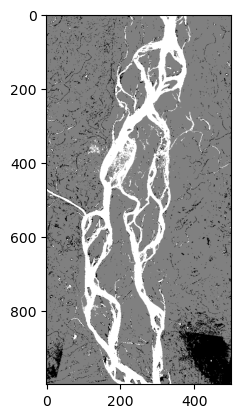

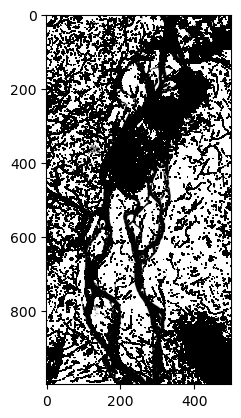

In [ ]:
zero_indeces = img_bad == 0
img_bad_improved = img_bad.copy()  
img_bad_improved[zero_indeces] = averaged_image[zero_indeces]
diff_image_improved = img_bad - img_bad_improved
plt.imshow(img_bad_improved, vmin=vmin, vmax=vmax)
plt.show()
plt.imshow(diff_image_improved, vmin=254, vmax=255)
plt.show()

In [63]:
for i in range(-3,257):
    if len(diff_image_improved[diff_image_improved==i]) != 0:
        print(f'{i}: {len(diff_image_improved[diff_image_improved==i])}')

0: 499988
254: 9
255: 3


**<span style="color:red">Attention!</span> Don't run the following cells unless needed. If this is done, the files created will be overwritten.**

This cell generates <code>*.csv</code> files for each folder (i.e., combination of use and reach id) by setting a <code>no-data</code> and <code>water</code> thresholds.

In [10]:
nodata = 300000
water = 17500

# training dataset
clear_single_df(train, nodata, water)

# validation dataset
clear_single_df(val, nodata, water)

# testing dataset
clear_single_df(test, nodata, water)

The next cell performs the same operation of the above one but does so combining all reaches of a given use (training, validation and testing).

In [ ]:
# lists containing ranges for no-data and water max/min values 

nodata_list = [225000, 250000, 275000, 300000, 325000, 350000]
water_list = [10000, 12500, 15000, 17500, 20000, 22500, 25000, 27500]

# loops through the above lists to check available images given different combinations of thresholds 
# loop also through training, validation and testing

for nodata in nodata_list:
    for water in water_list:
        for train_val_test in train_val_test_list:
            clear_full_df(train_val_test, nodata, water)

------

In [82]:
best_train1 = imgs_for_dataset(train, 1)

In [85]:
best_test1 = imgs_for_dataset(test, 1)

In [87]:
best_test1

,Date image,Use,Reach,no-data: 0,non-water: 1,water: 2,Group
0,1987-12-01,testing,1,9612,410716,79672,0
6,1988-06-01,testing,1,131049,281593,87358,Monsoon 1
15,1989-03-01,testing,1,330,439973,59697,1
22,1989-10-01,testing,1,11724,306456,181820,Monsoon 2
23,1989-11-01,testing,1,952,373543,125505,2
...,...,...,...,...,...,...,...
383,2019-11-01,testing,1,0,399318,100682,32
389,2020-05-01,testing,1,32,429948,70020,Monsoon 33
400,2021-04-01,testing,1,0,443294,56706,33
406,2021-10-01,testing,1,11879,366064,122057,Monsoon 34


In [83]:
print(best_train1.to_markdown())

|     | Date image   | Use      |   Reach |   no-data: 0 |   non-water: 1 |   water: 2 | Group      |
|----:|:-------------|:---------|--------:|-------------:|---------------:|-----------:|:-----------|
|   0 | 1987-12-01   | training |       1 |         9513 |         406447 |      84040 | 0          |
|   6 | 1988-06-01   | training |       1 |       178312 |         222054 |      99634 | Monsoon 1  |
|  11 | 1988-11-01   | training |       1 |          706 |         385617 |     113677 | 1          |
|  22 | 1989-10-01   | training |       1 |       137464 |         218251 |     144285 | Monsoon 2  |
|  23 | 1989-11-01   | training |       1 |        10555 |         386955 |     102490 | 2          |
|  29 | 1990-05-01   | training |       1 |         3606 |         380667 |     115727 | Monsoon 3  |
|  35 | 1990-11-01   | training |       1 |         3818 |         395356 |     100826 | 3          |
|  41 | 1991-05-01   | training |       1 |       213708 |         220575 |      6

c:\Users\magherin\AppData\Local\anaconda3\envs\braided\lib\site-packages\osgeo\gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


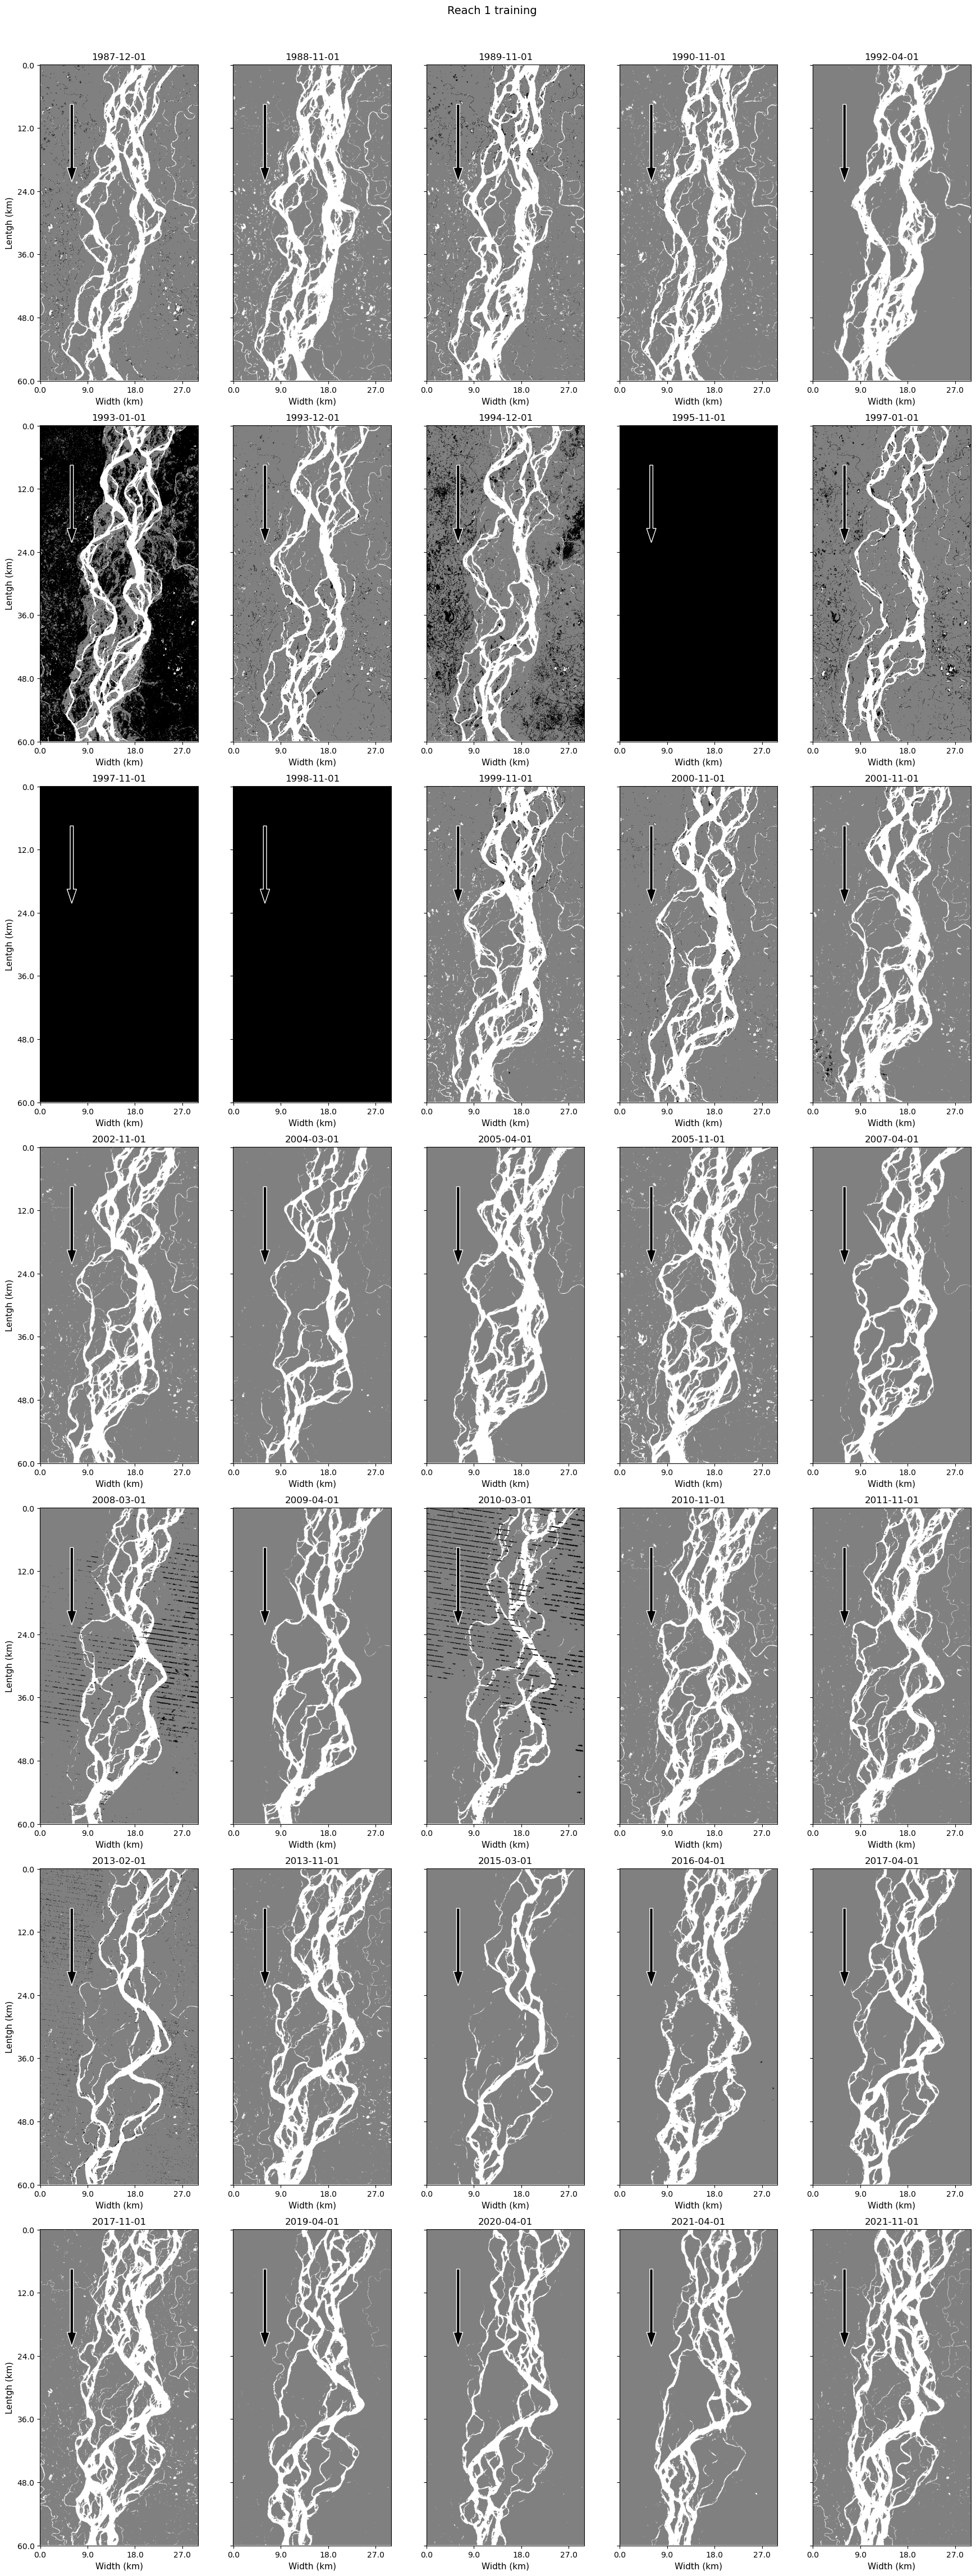

In [10]:
plot_input_images(train, 1)